this file will clean the dataset and define the `severity_index` output variable
that will be used as ground truth for evaluating our fuzzy logic system

In [1]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv("../data/globalterrorismdb_0718dist.csv", encoding="latin-1", low_memory=False)

cols = [
    "iyear", "region_txt", "country_txt",
    "attacktype1_txt", "weaptype1_txt",
    "nkill", "nwound", "propextent", "success"
]

df = df_raw[cols].copy()
print(f"Raw rows: {len(df):,}")

Raw rows: 181,691


In [2]:
# fill missing casualties with 0 (no reported = 0)
df["nkill"] = df["nkill"].fillna(0)
df["nwound"] = df["nwound"].fillna(0)

# propextent: 4 = unknown, fill missing with 4
df["propextent"] = df["propextent"].fillna(4)

# drop unknown attack types
df = df[df["attacktype1_txt"] != "Unknown"].reset_index(drop=True)

print(f"Clean rows: {len(df):,}")
print(df.isnull().sum())

Clean rows: 174,415
iyear              0
region_txt         0
country_txt        0
attacktype1_txt    0
weaptype1_txt      0
nkill              0
nwound             0
propextent         0
success            0
dtype: int64


## Defining Severity Index

We define `severity_index` as a composite score from three factors:

| Component | Weight | Reasoning |
|---|---|---|
| Fatalities (`nkill`) | 0.5 | Most critical indicator |
| Injuries (`nwound`) | 0.3 | Secondary human impact |
| Property damage (`propextent`) | 0.2 | Physical/economic impact |

`propextent` in GTD is coded as:
- 1 = Catastrophic (>$1B)
- 2 = Major
- 3 = Minor
- 4 = Unknown

We invert it (4 -> 0, 1 -> 3) so higher = more damage.

Final score is normalized to 0–100 range, then binned into:
- **Low** (0–25)
- **Medium** (25–50)
- **High** (50–75)
- **Critical** (75–100)

In [3]:
# normalize nkill and nwound using 95th percentile as cap
kill_cap = df["nkill"].quantile(0.95)
wound_cap = df["nwound"].quantile(0.95)

nkill_norm = (df["nkill"].clip(upper=kill_cap) / kill_cap) * 100
nwound_norm = (df["nwound"].clip(upper=wound_cap) / wound_cap) * 100

# invert propextent: 1→3, 2→2, 3→1, 4→0
prop_inverted = df["propextent"].map({1: 3, 2: 2, 3: 1, 4: 0})
prop_norm = (prop_inverted / 3) * 100

# weighted composite score
df["severity_score"] = (
    0.5 * nkill_norm +
    0.3 * nwound_norm +
    0.2 * prop_norm
)

# bin into severity categories
def categorize(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Medium"
    elif score < 75:
        return "High"
    else:
        return "Critical"

df["severity_index"] = df["severity_score"].apply(categorize)

print(df["severity_index"].value_counts())
print()
print(df[["nkill", "nwound", "propextent", "severity_score", "severity_index"]].head(10))

severity_index
Low         143949
Medium       17186
High          9403
Critical      3877
Name: count, dtype: int64

   nkill  nwound  propextent  severity_score severity_index
0    1.0     0.0         4.0        5.555556            Low
1    0.0     0.0         4.0        0.000000            Low
2    1.0     0.0         4.0        5.555556            Low
3    0.0     0.0         4.0        0.000000            Low
4    0.0     0.0         4.0        0.000000            Low
5    0.0     0.0         3.0        6.666667            Low
6    0.0     0.0         4.0        0.000000            Low
7    0.0     0.0         3.0        6.666667            Low
8    0.0     0.0         3.0        6.666667            Low
9    0.0     0.0         3.0        6.666667            Low


/var/folders/3x/7sk21yf90pj75zctn41pj9s80000gn/T/ipykernel_1453/64161330.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="severity_index", order=order, palette="Reds", ax=axes[0])


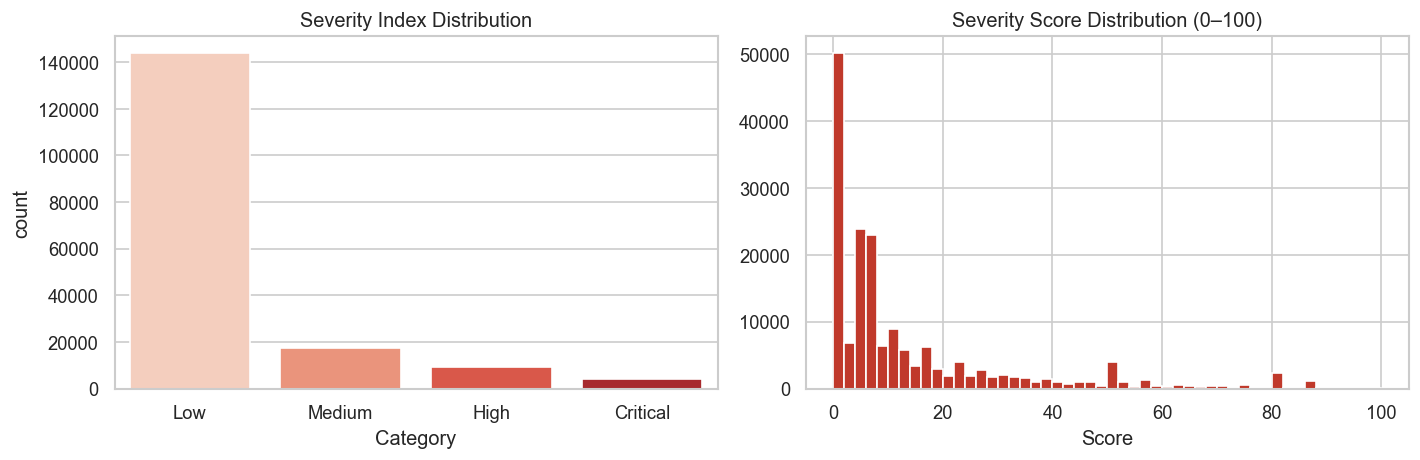

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# severity category distribution
order = ["Low", "Medium", "High", "Critical"]
sns.countplot(data=df, x="severity_index", order=order, palette="Reds", ax=axes[0])
axes[0].set_title("Severity Index Distribution")
axes[0].set_xlabel("Category")

# severity score histogram
df["severity_score"].hist(bins=50, ax=axes[1], color="#c0392b", edgecolor="white")
axes[1].set_title("Severity Score Distribution (0–100)")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()

In [5]:
df.to_csv("../data/gtd_processed.csv", index=False)
print("Saved to data/gtd_processed.csv")
print(f"Final shape: {df.shape}")

Saved to data/gtd_processed.csv
Final shape: (174415, 11)


## Summary

- Raw dataset: **181,691 rows**, 135 columns
- After removing unknown attack types: **174,415 rows**
- No missing values remain after cleaning
- Output variable `severity_index` defined from weighted composite score:
  - 50% fatalities (`nkill`)
  - 30% injuries (`nwound`)
  - 20% property damage (`propextent`, inverted)
- Distribution reflects real-world skew most attacks are low severity:
  - Low: 143,949 (82.5%)
  - Medium: 17,186 (9.9%)
  - High: 9,403 (5.4%)
  - Critical: 3,877 (2.2%)
- Processed file saved locally to `data/gtd_processed.csv` (not pushed to GitHub)
- Ready for fuzzy membership function design